# Lab 3: T-test and ANOVA

In [2]:
!pip install -U pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 6.2 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import numpy as np
import pandas as pd
os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
import seaborn as sns

import pingouin as pg
## https://pingouin-stats.org/build/html/index.html


#from shapely.geometry import Point
#from scipy import stats
#from scipy import special
#from tqdm import tqdm
#import mapclassify as mc

In [5]:
data_dir = './drive/MyDrive/GE5230-2510/data_base/'
os.listdir(data_dir)

['master-plan-2019-subzone_landuse_area.dbf',
 'master-plan-2019-subzone_landuse_area.prj',
 'master-plan-2019-subzone_landuse_area.cpg',
 'master-plan-2019-subzone_landuse_area.shx',
 'master-plan-2019-subzone_landuse_area.shp',
 'master-plan-2019-planningarea.dbf',
 'master-plan-2019-planningarea.qmd',
 'master-plan-2019-planningarea.prj',
 'master-plan-2019-planningarea.shx',
 'master-plan-2019-planningarea.shp',
 'master-plan-2019-planningarea.cpg',
 'hdb_data_2023.csv.xz',
 'hdb_data_2013.csv.xz']

<Axes: >

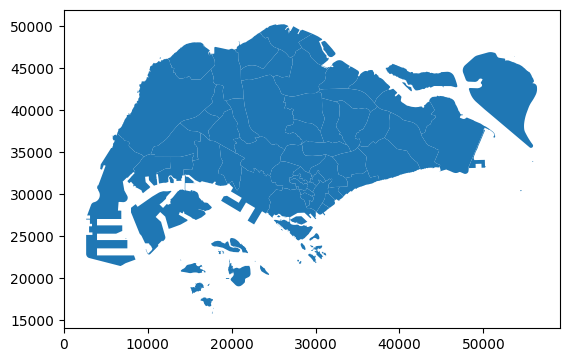

In [6]:
gdf_pa = gpd.read_file(os.path.join(data_dir, 'master-plan-2019-planningarea.shp'))
gdf_pa = gdf_pa.to_crs('epsg:3414')
gdf_pa.plot()

In [7]:
gdf_pa.head()

,Name,SUBZONE_NO,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C,PA_Rakuten,geometry
0,kml_280,3,BAHAR,WCSZ03,WESTERN WATER CATCHMENT,WC,WEST REGION,WR,WESTERN WATER CATCHM,"MULTIPOLYGON Z (((12927.538 37463.172 0, 12908..."
1,kml_57,8,CLEMENTI WEST,CLSZ08,CLEMENTI,CL,WEST REGION,WR,CLEMENTI,"POLYGON Z ((20732.662 30538.928 0, 20714.848 3..."
2,kml_49,6,MACKENZIE,RCSZ06,ROCHOR,RC,CENTRAL REGION,CR,ROCHOR,"POLYGON Z ((30306.001 31670.652 0, 30312.536 3..."
3,kml_221,7,CONEY ISLAND,PGSZ07,PUNGGOL,PG,NORTH-EAST REGION,NER,PUNGGOL,"POLYGON Z ((37558.956 41724.067 0, 37535.685 4..."
4,kml_273,1,CENTRAL WATER CATCHMENT,CCSZ01,CENTRAL WATER CATCHMENT,CC,NORTH REGION,NR,CENTRAL WATER CATCHM,"POLYGON Z ((25073.293 43675.363 0, 25130.764 4..."


In [8]:
gdf_reg = gdf_pa.dissolve('REGION_N').reset_index()
gdf_reg.head()

,REGION_N,geometry,Name,SUBZONE_NO,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_C,PA_Rakuten
0,CENTRAL REGION,"MULTIPOLYGON Z (((28342.972 21768.002 0, 28364...",kml_49,6,MACKENZIE,RCSZ06,ROCHOR,RC,CR,ROCHOR
1,EAST REGION,"MULTIPOLYGON Z (((54538.495 30472.993 0, 54540...",kml_160,2,PAYA LEBAR EAST,PLSZ02,PAYA LEBAR,PL,ER,PAYA LEBAR
2,NORTH REGION,"MULTIPOLYGON Z (((26362.719 41636.901 0, 26334...",kml_273,1,CENTRAL WATER CATCHMENT,CCSZ01,CENTRAL WATER CATCHMENT,CC,NR,CENTRAL WATER CATCHM
3,NORTH-EAST REGION,"MULTIPOLYGON Z (((34882.61 35431.559 0, 34845....",kml_221,7,CONEY ISLAND,PGSZ07,PUNGGOL,PG,NER,PUNGGOL
4,WEST REGION,"MULTIPOLYGON Z (((16355.312 19423.043 0, 16383...",kml_280,3,BAHAR,WCSZ03,WESTERN WATER CATCHMENT,WC,WR,WESTERN WATER CATCHM


In [9]:
gdf_reg = gdf_reg[['geometry', 'REGION_N', 'REGION_C']]
gdf_reg.head()

,geometry,REGION_N,REGION_C
0,"MULTIPOLYGON Z (((28342.972 21768.002 0, 28364...",CENTRAL REGION,CR
1,"MULTIPOLYGON Z (((54538.495 30472.993 0, 54540...",EAST REGION,ER
2,"MULTIPOLYGON Z (((26362.719 41636.901 0, 26334...",NORTH REGION,NR
3,"MULTIPOLYGON Z (((34882.61 35431.559 0, 34845....",NORTH-EAST REGION,NER
4,"MULTIPOLYGON Z (((16355.312 19423.043 0, 16383...",WEST REGION,WR


<Axes: >

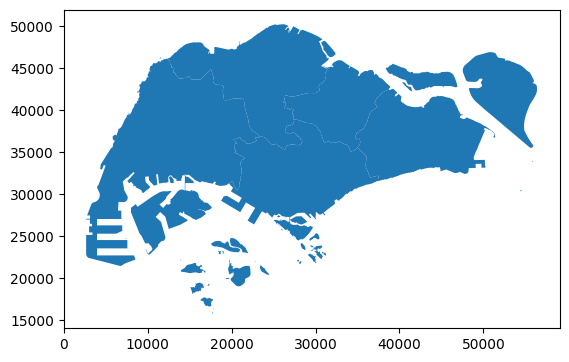

In [10]:
gdf_reg.plot()

In [12]:
f = os.path.join(data_dir, 'hdb_data_2023.csv.xz')
df23 = pd.read_csv(f, index_col=0)
df23.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,resale_year,resale_month,resale_age,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry
0,2023-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,01 TO 03,44.0,Improved,1979,267000.0,2023,1,44,406 ANG MO KIO AVE 10,1.362005,103.853880,30288.234663,38229.067463,560406,POINT (30288.2346631354 38229.0674628187)
1,2023-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,49.0,Improved,1977,300000.0,2023,1,46,323 ANG MO KIO AVE 3,1.367908,103.847714,29602.047153,38881.891694,560323,POINT (29602.0471531954 38881.8916942235)
2,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,280000.0,2023,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912)
3,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1978,282000.0,2023,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912)
4,2023-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,289800.0,2023,1,37,170 ANG MO KIO AVE 4,1.374001,103.836432,28346.433332,39555.534275,560170,POINT (28346.4333322113 39555.5342750959)


In [13]:
f = os.path.join(data_dir, 'hdb_data_2013.csv.xz')
df13 = pd.read_csv(f, index_col=0)
df13.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,resale_year,resale_month,resale_age,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry
0,2013-01,ANG MO KIO,2 ROOM,510,ANG MO KIO AVE 8,01 TO 03,44.0,Improved,1980,253000.0,2013,1,33,510 ANG MO KIO AVE 8,1.373401,103.849073,29753.300929,39489.217940,560510,POINT (29753.3009291003 39489.2179400064)
1,2013-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,01 TO 03,44.0,Improved,1978,270000.0,2013,1,35,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912)
2,2013-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1977,283000.0,2013,1,36,323 ANG MO KIO AVE 3,1.367908,103.847714,29602.047153,38881.891694,560323,POINT (29602.0471531954 38881.8916942235)
3,2013-01,ANG MO KIO,3 ROOM,170,ANG MO KIO AVE 4,07 TO 09,61.0,Improved,1986,305000.0,2013,1,27,170 ANG MO KIO AVE 4,1.374001,103.836432,28346.433332,39555.534275,560170,POINT (28346.4333322113 39555.5342750959)
4,2013-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,01 TO 03,60.0,Improved,1986,320000.0,2013,1,27,174 ANG MO KIO AVE 4,1.375097,103.837619,28478.579445,39676.807613,560174,POINT (28478.5794445509 39676.8076131288)


In [14]:
df = pd.concat([df13, df23])

In [15]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,resale_year,resale_month,resale_age,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry
0,2013-01,ANG MO KIO,2 ROOM,510,ANG MO KIO AVE 8,01 TO 03,44.0,Improved,1980,253000.0,2013,1,33,510 ANG MO KIO AVE 8,1.373401,103.849073,29753.300929,39489.217940,560510,POINT (29753.3009291003 39489.2179400064)
1,2013-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,01 TO 03,44.0,Improved,1978,270000.0,2013,1,35,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912)
2,2013-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1977,283000.0,2013,1,36,323 ANG MO KIO AVE 3,1.367908,103.847714,29602.047153,38881.891694,560323,POINT (29602.0471531954 38881.8916942235)
3,2013-01,ANG MO KIO,3 ROOM,170,ANG MO KIO AVE 4,07 TO 09,61.0,Improved,1986,305000.0,2013,1,27,170 ANG MO KIO AVE 4,1.374001,103.836432,28346.433332,39555.534275,560170,POINT (28346.4333322113 39555.5342750959)
4,2013-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,01 TO 03,60.0,Improved,1986,320000.0,2013,1,27,174 ANG MO KIO AVE 4,1.375097,103.837619,28478.579445,39676.807613,560174,POINT (28478.5794445509 39676.8076131288)


<Axes: >

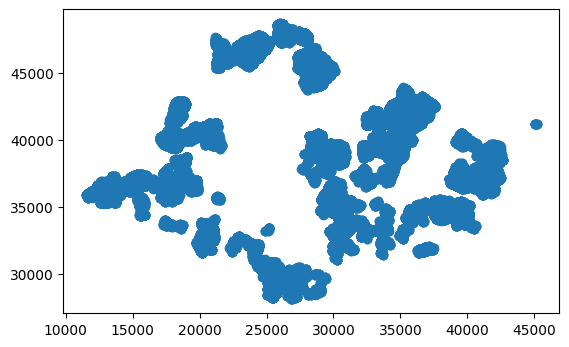

In [16]:
gdf = gpd.GeoDataFrame(data=df,
                       geometry=df['geometry'].apply(wkt.loads), crs='epsg:3414')
gdf.plot()

<Axes: >

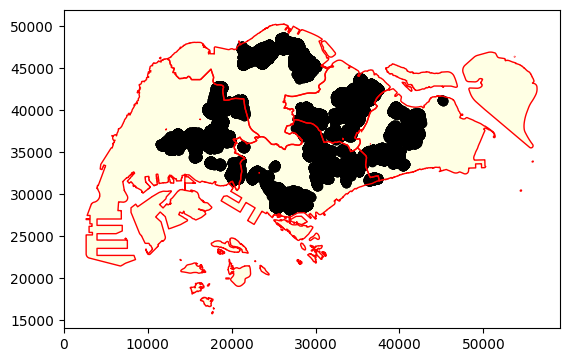

In [17]:
fig, ax = plt.subplots()
gdf_reg.plot(fc='xkcd:off white', ax=ax)
gdf.plot(color='k', ax=ax)
gdf_reg.plot(fc='none', ec='red', ax=ax)

In [18]:
df['town'].unique()

array(['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH',
       'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG',
       'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST',
       'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL',
       'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES',
       'TOA PAYOH', 'WOODLANDS', 'YISHUN'], dtype=object)

In [19]:
gdf2 = gdf.sjoin(gdf_reg)
gdf2.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry,index_right,REGION_N,REGION_C
0,2013-01,ANG MO KIO,2 ROOM,510,ANG MO KIO AVE 8,01 TO 03,44.0,Improved,1980,253000.0,...,510 ANG MO KIO AVE 8,1.373401,103.849073,29753.300929,39489.217940,560510,POINT (29753.301 39489.218),3,NORTH-EAST REGION,NER
1,2013-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,01 TO 03,44.0,Improved,1978,270000.0,...,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.998 38695.97),3,NORTH-EAST REGION,NER
2,2013-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1977,283000.0,...,323 ANG MO KIO AVE 3,1.367908,103.847714,29602.047153,38881.891694,560323,POINT (29602.047 38881.892),3,NORTH-EAST REGION,NER
3,2013-01,ANG MO KIO,3 ROOM,170,ANG MO KIO AVE 4,07 TO 09,61.0,Improved,1986,305000.0,...,170 ANG MO KIO AVE 4,1.374001,103.836432,28346.433332,39555.534275,560170,POINT (28346.433 39555.534),3,NORTH-EAST REGION,NER
4,2013-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,01 TO 03,60.0,Improved,1986,320000.0,...,174 ANG MO KIO AVE 4,1.375097,103.837619,28478.579445,39676.807613,560174,POINT (28478.579 39676.808),3,NORTH-EAST REGION,NER


<Axes: >

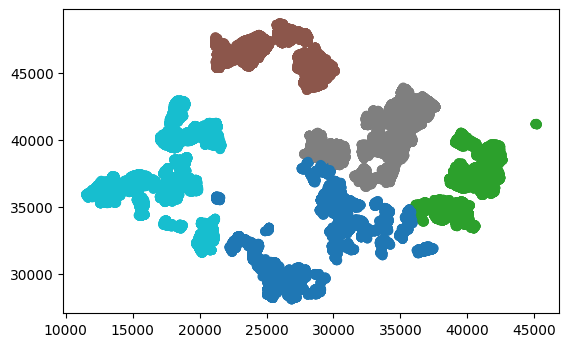

In [42]:
gdf2.plot('REGION_N')

In [20]:
gdf13 = gdf2[gdf2['resale_year']==2013]
gdf23 = gdf2[gdf2['resale_year']==2023]
len(gdf13), len(gdf23), len(df13), len(df23)

(16097, 25760, 16097, 25760)

<Axes: >

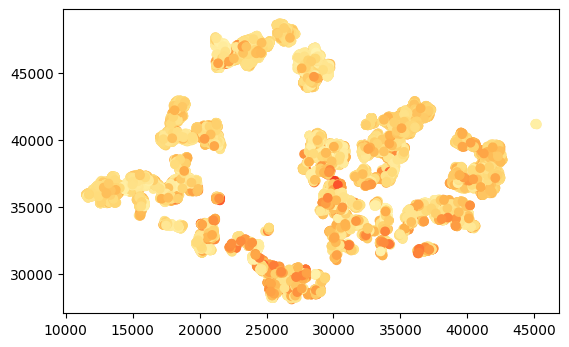

In [21]:
gdf13.plot('resale_price', 'YlOrRd', vmin=gdf2['resale_price'].min(), vmax=gdf2['resale_price'].max())

<Axes: >

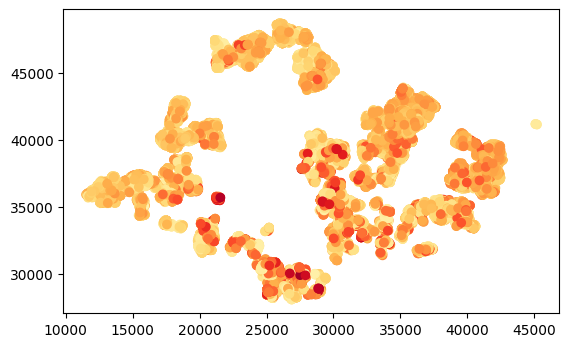

In [22]:
gdf23.plot('resale_price', 'YlOrRd', vmin=gdf2['resale_price'].min(), vmax=gdf2['resale_price'].max())

In [23]:
gdf13 = gdf13.sort_values(by='resale_price')
gdf23 = gdf23.sort_values(by='resale_price')

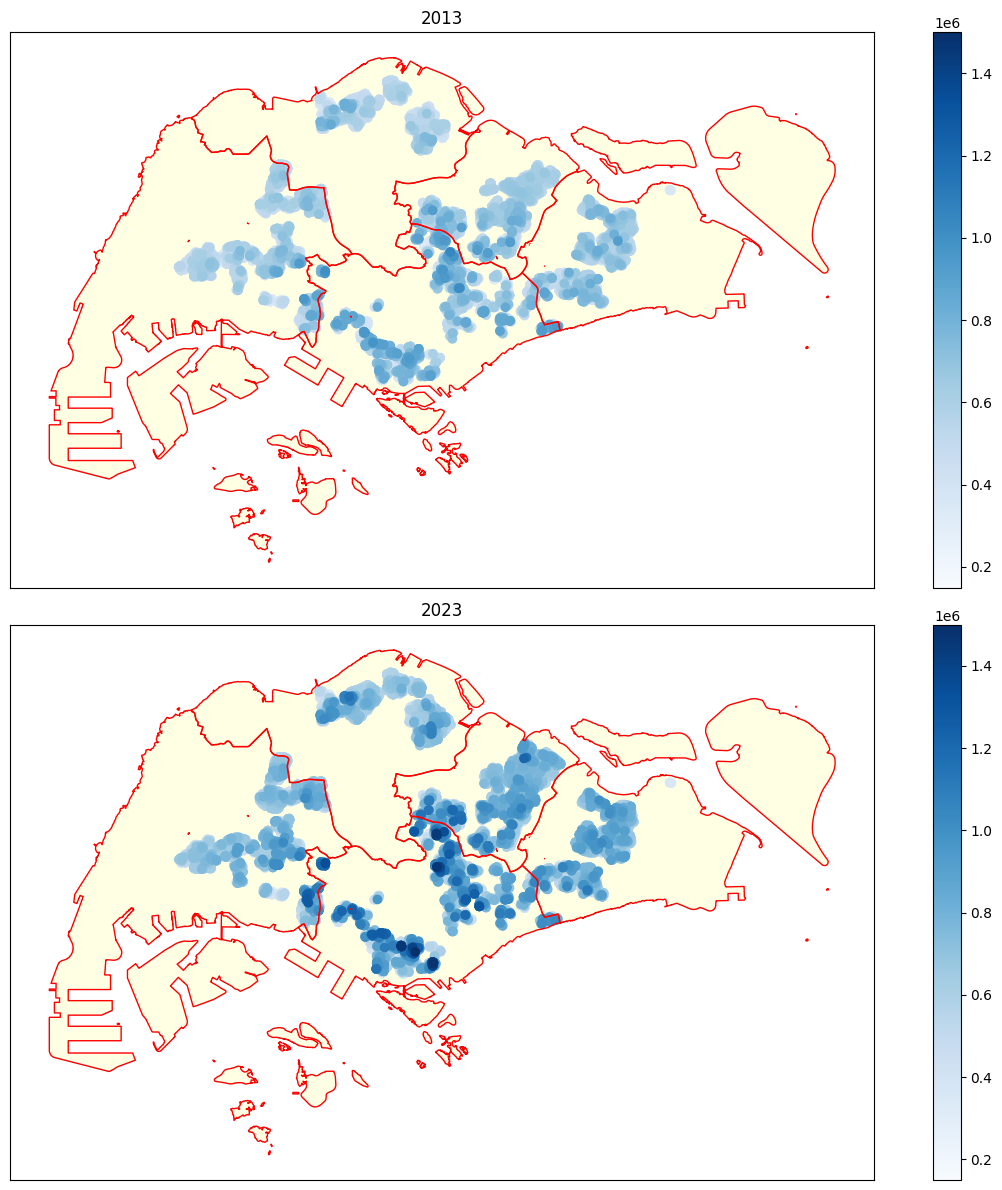

In [24]:
fig, axs = plt.subplots(2, 1, figsize=(12, 12))
for ax in axs:
    gdf_reg.plot(fc='xkcd:off white', ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])

gdf13.plot('resale_price', 'Blues',
            vmin=gdf2['resale_price'].min(), vmax=gdf2['resale_price'].max(), ax=axs[0],
            legend=True,
            )
gdf23.plot('resale_price', 'Blues',
            vmin=gdf2['resale_price'].min(), vmax=gdf2['resale_price'].max(), ax=axs[1],
            legend=True,
            )
titles = [2013, 2023]
for i, ax in enumerate(axs):
    gdf_reg.plot(fc='none', ec='red', ax=ax)
    ax.set_title(titles[i])
plt.tight_layout()
fig.savefig('HDB_price_points_13_23.png', dpi=200, bbox_inches='tight')

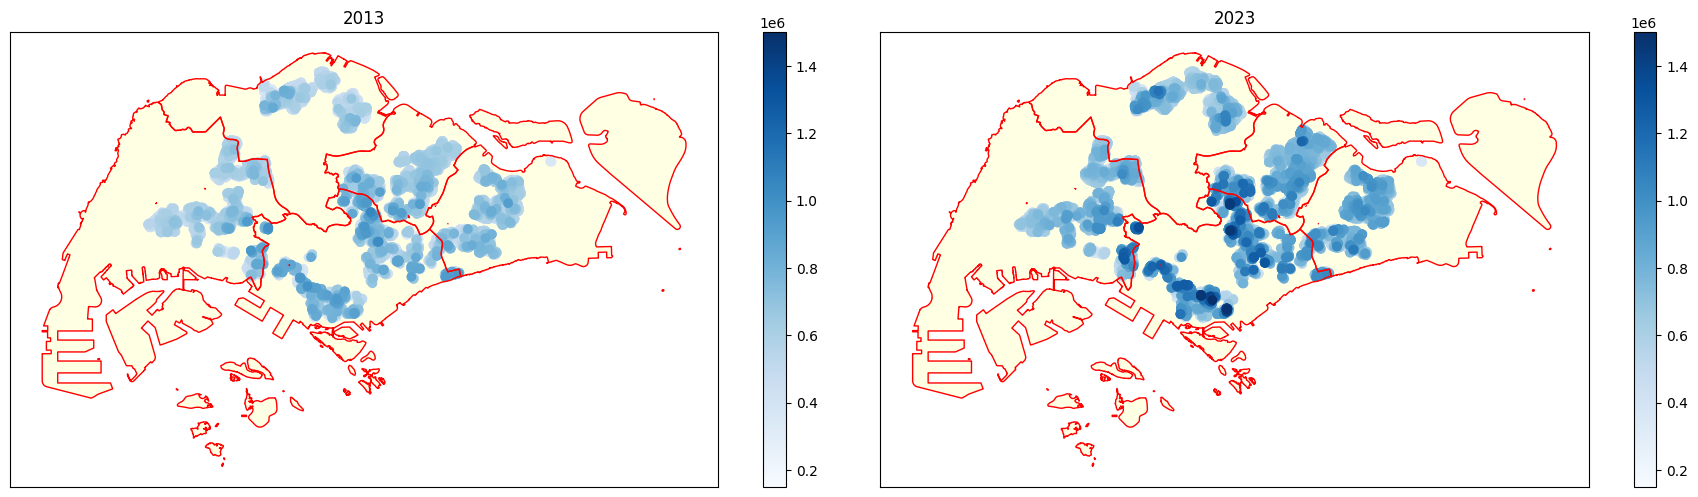

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(18, 5))
for ax in axs:
    gdf_reg.plot(fc='xkcd:off white', ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])

gdf13.plot('resale_price', 'Blues',
            vmin=gdf2['resale_price'].min(), vmax=gdf2['resale_price'].max(), ax=axs[0],
            legend=True,
            )
gdf23.plot('resale_price', 'Blues',
            vmin=gdf2['resale_price'].min(), vmax=gdf2['resale_price'].max(), ax=axs[1],
            legend=True,
            )
titles = [2013, 2023]
for i, ax in enumerate(axs):
    gdf_reg.plot(fc='none', ec='red', ax=ax)
    ax.set_title(titles[i])
plt.tight_layout()
fig.savefig('HDB_price_points_13_23.png', dpi=200, bbox_inches='tight')

## for running t-test

In [25]:
gdf23.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry,index_right,REGION_N,REGION_C
25473,2023-12,WOODLANDS,2 ROOM,182A,WOODLANDS ST 13,28 TO 30,47.0,Model A,2019,150000.0,...,182A WOODLANDS ST 13,1.435697,103.775516,21567.424708,46377.627619,731182,POINT (21567.425 46377.628),2,NORTH REGION,NR
16901,2023-08,TAMPINES,3 ROOM,522A,TAMPINES CTRL 7,07 TO 09,67.0,Model A,2015,150000.0,...,522A TAMPINES CTRL 7,1.357769,103.938392,39693.460573,37760.982599,521522,POINT (39693.461 37760.983),1,EAST REGION,ER
9548,2023-05,GEYLANG,2 ROOM,51,CIRCUIT RD,07 TO 09,42.0,Standard,1969,217000.0,...,51 CIRCUIT RD,1.324520,103.885515,33808.890421,34084.320144,370051,POINT (33808.89 34084.32),0,CENTRAL REGION,CR
18659,2023-09,QUEENSTOWN,2 ROOM,18,GHIM MOH RD,04 TO 06,45.0,Improved,1977,228000.0,...,18 GHIM MOH RD,1.310151,103.787082,22854.350092,32495.356241,270018,POINT (22854.35 32495.356),0,CENTRAL REGION,CR
19806,2023-10,BUKIT MERAH,1 ROOM,7,TELOK BLANGAH CRES,04 TO 06,31.0,Improved,1975,229000.0,...,7 TELOK BLANGAH CRES,1.278361,103.819384,26449.194373,28980.230080,090007,POINT (26449.194 28980.23),0,CENTRAL REGION,CR


<Axes: xlabel='resale_price', ylabel='Density'>

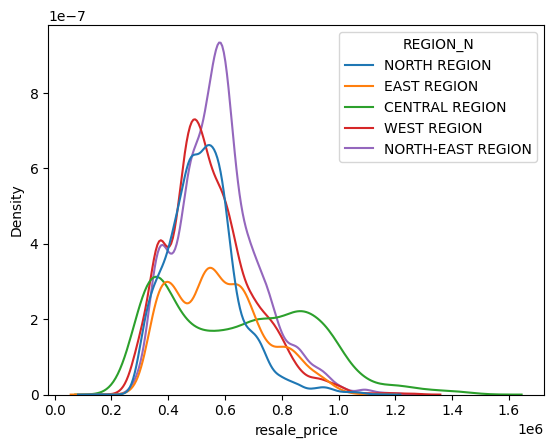

In [26]:
sns.kdeplot(x='resale_price', hue='REGION_N', data=gdf23)
#sns.kdeplot(x='resale_price', hue='REGION_N', data=gdf2, hue_order=['EAST REGION', 'WEST REGION'])

In [27]:
df_east = gdf23[gdf23['REGION_C']=='ER']
df_west = gdf23[gdf23['REGION_C']=='WR']
df_central = gdf23[gdf23['REGION_C']=='CR']
df_north = gdf23[gdf23['REGION_C']=='NR']
df_northeast = gdf23[gdf23['REGION_C']=='NER']
#tmp = pd.concat([df_east, df_west])
#len(tmp), len(df_east), len(df_west)

In [31]:
pg.ttest(df_east['resale_price'], df_west['resale_price'],
         paired=False, alternative='two-sided',
         correction='auto', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,9.341376,7089.373191,two-sided,1.248663e-20,"[24363.3, 37304.33]",0.201765,1.621e+17,1.0


In [32]:
pg.ttest(df_east['resale_price'], df_west['resale_price'],
         paired=False, alternative='greater',
         correction='auto', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,9.341376,7089.373191,greater,6.243317e-21,"[25403.81, inf]",0.201765,3.241e+17,1.0


In [33]:
pg.ttest(df_east['resale_price'], df_west['resale_price'],
         paired=False, alternative='less',
         correction='auto', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,9.341376,7089.373191,less,1.0,"[-inf, 36263.82]",0.201765,3.085e-18,4.401175e-29


east's transactions are more expensive than west

In [34]:
pg.ttest(df_north['resale_price'], df_west['resale_price'],
         paired=False, alternative='less',
         correction='auto', r=0.707, confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-8.61138,10786.989365,less,4.111508e-18,"[-inf, -18208.58]",0.163683,4.628e+14,1.0


## for running ANOVA + post-hoc

In [35]:
pg.homoscedasticity(gdf23, dv='resale_price', group='REGION_C', method='levene', alpha=0.05)

,W,pval,equal_var
levene,1237.579933,0.0,False


In [36]:
pg.homoscedasticity(gdf23, dv='resale_price', group='REGION_C', method='bartlett', alpha=0.05)

,T,pval,equal_var
bartlett,3565.719937,0.0,False


both methods indicate the variances are not equal

In [37]:
pg.welch_anova(data=gdf23, dv='resale_price', between='REGION_C')

,Source,ddof1,ddof2,F,p-unc,np2
0,REGION_C,4,11628.378444,276.487914,1.967694e-227,0.051257


In [40]:
pg.anova(data=gdf23, dv='resale_price', between='REGION_C', ss_type=2, detailed=False, effsize='np2')  # not accurate

,Source,ddof1,ddof2,F,p-unc,np2
0,REGION_C,4,25755,347.860868,3.560629e-292,0.051257


In [ ]:
pg.pairwise_gameshowell(data=gdf23, dv='resale_price', between='REGION_C', effsize='hedges')

,A,B,mean(A),mean(B),diff,se,T,df,pval,CLES
0,CR,ER,645455.732427,576955.607904,68500.124523,4703.094012,14.564906,7615.025607,3.790634e-12,0.561147
1,CR,NER,645455.732427,577333.310370,68122.422057,4234.351894,16.088040,6285.594647,1.759481e-12,0.560080
2,CR,NR,645455.732427,523613.563076,121842.169351,4249.209688,28.674078,6289.833898,6.426082e-12,0.618943
3,CR,WR,645455.732427,546121.790617,99333.941810,4323.116388,22.977392,6687.759693,1.272982e-12,0.596101
4,ER,NER,576955.607904,577333.310370,-377.702467,3183.636561,-0.118639,6559.848843,9.999554e-01,0.494578
5,ER,NR,576955.607904,523613.563076,53342.044827,3203.371468,16.651845,6441.572153,0.000000e+00,0.594307
6,ER,WR,576955.607904,546121.790617,30833.817287,3300.778862,9.341376,7089.373191,0.000000e+00,0.556287
7,NER,NR,577333.310370,523613.563076,53719.747294,2464.189814,21.800166,11368.934448,0.000000e+00,0.615474
8,NER,WR,577333.310370,546121.790617,31211.519753,2589.552813,12.052861,12353.042507,2.593703e-12,0.570430
9,NR,WR,523613.563076,546121.790617,-22508.227541,2613.777110,-8.611380,10786.989365,0.000000e+00,0.463626


In [ ]:
pg.pairwise_tukey(data=gdf23, dv='resale_price', between='REGION_C', effsize='hedges')  # not accurate

,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,CR,ER,645455.732427,576955.607904,68500.124523,3797.955438,18.036053,0.000000e+00,0.310362
1,CR,NER,645455.732427,577333.310370,68122.422057,3245.723987,20.988360,0.000000e+00,0.345471
2,CR,NR,645455.732427,523613.563076,121842.169351,3500.485604,34.807219,0.000000e+00,0.609033
3,CR,WR,645455.732427,546121.790617,99333.941810,3353.888151,29.617548,0.000000e+00,0.487580
4,ER,NER,576955.607904,577333.310370,-377.702467,3490.045918,-0.108223,9.999691e-01,-0.002531
5,ER,NR,576955.607904,523613.563076,53342.044827,3728.149109,14.307916,0.000000e+00,0.381556
6,ER,WR,576955.607904,546121.790617,30833.817287,3590.858121,8.586755,0.000000e+00,0.201749
7,NER,NR,577333.310370,523613.563076,53719.747294,3163.756386,16.979736,0.000000e+00,0.396851
8,NER,WR,577333.310370,546121.790617,31211.519753,3000.753361,10.401228,0.000000e+00,0.214175
9,NR,WR,523613.563076,546121.790617,-22508.227541,3274.629139,-6.873520,5.013467e-11,-0.163672


## for paired t test

<Axes: >

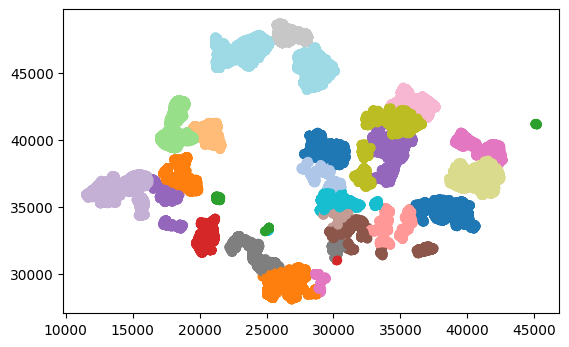

In [41]:
gdf3 = gdf.sjoin(gdf_pa)
gdf3.plot('PLN_AREA_N', cmap='tab20')

In [43]:
gdf3

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,index_right,Name,SUBZONE_NO,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C,PA_Rakuten
0,2013-01,ANG MO KIO,2 ROOM,510,ANG MO KIO AVE 8,01 TO 03,44.0,Improved,1980,253000.0,...,18,kml_163,3,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER,ANG MO KIO
1,2013-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,01 TO 03,44.0,Improved,1978,270000.0,...,18,kml_163,3,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER,ANG MO KIO
2,2013-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1977,283000.0,...,18,kml_163,3,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER,ANG MO KIO
3,2013-01,ANG MO KIO,3 ROOM,170,ANG MO KIO AVE 4,07 TO 09,61.0,Improved,1986,305000.0,...,18,kml_163,3,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER,ANG MO KIO
4,2013-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,01 TO 03,60.0,Improved,1986,320000.0,...,18,kml_163,3,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER,ANG MO KIO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25755,2023-12,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,146.0,Maisonette,1987,838000.0,...,17,kml_219,8,KHATIB,YSSZ08,YISHUN,YS,NORTH REGION,NR,YISHUN
25756,2023-12,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,142.0,Apartment,1987,755000.0,...,17,kml_219,8,KHATIB,YSSZ08,YISHUN,YS,NORTH REGION,NR,YISHUN
25757,2023-12,YISHUN,EXECUTIVE,826,YISHUN ST 81,01 TO 03,142.0,Apartment,1988,780000.0,...,17,kml_219,8,KHATIB,YSSZ08,YISHUN,YS,NORTH REGION,NR,YISHUN
25758,2023-12,YISHUN,EXECUTIVE,834,YISHUN ST 81,01 TO 03,142.0,Apartment,1988,785000.0,...,17,kml_219,8,KHATIB,YSSZ08,YISHUN,YS,NORTH REGION,NR,YISHUN


In [44]:
pa_df_long = gdf3.groupby(['resale_year', 'PLN_AREA_N'])[['resale_price']].mean().reset_index()
pa_df_long

,resale_year,PLN_AREA_N,resale_price
0,2013,ANG MO KIO,434408.974490
1,2013,BEDOK,445668.299015
2,2013,BISHAN,603629.229452
3,2013,BUKIT BATOK,434037.287081
4,2013,BUKIT MERAH,578575.225434
...,...,...,...
57,2023,TAMPINES,593106.992656
58,2023,TANGLIN,770000.000000
59,2023,TOA PAYOH,587186.617889
60,2023,WOODLANDS,536766.417112


In [45]:
pa_df = pa_df_long.pivot(index='PLN_AREA_N', columns='resale_year', values='resale_price')
pa_df

resale_year,2013,2023
PLN_AREA_N,,
ANG MO KIO,434408.974490,536719.807541
BEDOK,445668.299015,523510.708397
BISHAN,603629.229452,774718.578947
BUKIT BATOK,434037.287081,572875.216142
BUKIT MERAH,578575.225434,699114.432683
BUKIT PANJANG,477689.564000,553162.123847
BUKIT TIMAH,676402.750000,843789.636364
CHANGI,316166.666667,341360.000000
CHOA CHU KANG,473499.892256,542365.773967


In [46]:
len(pa_df)

31

In [47]:
pg.ttest(pa_df[2013], pa_df[2023], paired=True, alternative='less',
         correction='auto', r=0.707, confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-8.545356,30,less,7.777661e-10,"[-inf, -80596.81]",1.055031,1.498e+07,0.999979


## for running repeated measure ANOVA (within group)

In [54]:
gdf3.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,index_right,Name,SUBZONE_NO,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C,PA_Rakuten
0,2013-01,ANG MO KIO,2 ROOM,510,ANG MO KIO AVE 8,01 TO 03,44.0,Improved,1980,253000.0,...,18,kml_163,3,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER,ANG MO KIO
1,2013-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,01 TO 03,44.0,Improved,1978,270000.0,...,18,kml_163,3,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER,ANG MO KIO
2,2013-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1977,283000.0,...,18,kml_163,3,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER,ANG MO KIO
3,2013-01,ANG MO KIO,3 ROOM,170,ANG MO KIO AVE 4,07 TO 09,61.0,Improved,1986,305000.0,...,18,kml_163,3,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER,ANG MO KIO
4,2013-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,01 TO 03,60.0,Improved,1986,320000.0,...,18,kml_163,3,CHONG BOON,AMSZ03,ANG MO KIO,AM,NORTH-EAST REGION,NER,ANG MO KIO


In [55]:
ft_df_long = gdf3.groupby(['resale_year', 'flat_type', 'PLN_AREA_N'])[['resale_price']].mean().reset_index()
ft_df_long

,resale_year,flat_type,PLN_AREA_N,resale_price
0,2013,1 ROOM,BUKIT MERAH,240083.333333
1,2013,2 ROOM,ANG MO KIO,279151.310345
2,2013,2 ROOM,BEDOK,278013.636364
3,2013,2 ROOM,BUKIT MERAH,290814.285714
4,2013,2 ROOM,GEYLANG,261916.666667
...,...,...,...,...
259,2023,EXECUTIVE,TAMPINES,870442.144000
260,2023,EXECUTIVE,TOA PAYOH,982828.666667
261,2023,EXECUTIVE,WOODLANDS,823537.115789
262,2023,EXECUTIVE,YISHUN,823621.081333


In [56]:
ft_df_long23 = ft_df_long[ft_df_long['resale_year']==2023]
ft_df_long23

,resale_year,flat_type,PLN_AREA_N,resale_price
124,2023,1 ROOM,BUKIT MERAH,243000.000000
125,2023,2 ROOM,ANG MO KIO,290945.333333
126,2023,2 ROOM,BEDOK,306200.000000
127,2023,2 ROOM,BUKIT BATOK,336507.936508
128,2023,2 ROOM,BUKIT MERAH,340259.259259
...,...,...,...,...
259,2023,EXECUTIVE,TAMPINES,870442.144000
260,2023,EXECUTIVE,TOA PAYOH,982828.666667
261,2023,EXECUTIVE,WOODLANDS,823537.115789
262,2023,EXECUTIVE,YISHUN,823621.081333


In [57]:
keep_type = ['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM']
ft_df_long23 = ft_df_long23[[ f in keep_type for f in ft_df_long23['flat_type']]]
ft_df_long23

,resale_year,flat_type,PLN_AREA_N,resale_price
125,2023,2 ROOM,ANG MO KIO,290945.333333
126,2023,2 ROOM,BEDOK,306200.000000
127,2023,2 ROOM,BUKIT BATOK,336507.936508
128,2023,2 ROOM,BUKIT MERAH,340259.259259
129,2023,2 ROOM,BUKIT PANJANG,307875.000000
...,...,...,...,...
233,2023,5 ROOM,TAMPINES,696617.684706
234,2023,5 ROOM,TANGLIN,970000.000000
235,2023,5 ROOM,TOA PAYOH,906060.955752
236,2023,5 ROOM,WOODLANDS,595777.069847


In [58]:
ft_df_23 = ft_df_long23.pivot(index='PLN_AREA_N', columns='flat_type', values='resale_price')
ft_df_23

flat_type,2 ROOM,3 ROOM,4 ROOM,5 ROOM
PLN_AREA_N,,,,
ANG MO KIO,290945.333333,400821.962894,6.488955e+05,8.070526e+05
BEDOK,306200.000000,380468.954064,5.720504e+05,7.056448e+05
BISHAN,NaN,444506.418605,7.072812e+05,9.141200e+05
BUKIT BATOK,336507.936508,400486.593407,5.871639e+05,7.621241e+05
BUKIT MERAH,340259.259259,496892.858817,8.033620e+05,9.348077e+05
BUKIT PANJANG,307875.000000,399947.163636,5.152374e+05,6.320705e+05
BUKIT TIMAH,NaN,456616.800000,7.569180e+05,1.059389e+06
CHANGI,NaN,341360.000000,NaN,NaN
CHOA CHU KANG,301900.000000,399154.376812,5.022802e+05,5.924874e+05


In [59]:
pg.rm_anova(data=ft_df_long23, dv='resale_price', within='flat_type', subject='PLN_AREA_N', correction='auto', detailed=False, effsize='ng2')

,Source,ddof1,ddof2,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher
0,flat_type,3,72,126.556037,1.227327e-28,1.394325e-12,0.712203,0.39094,False,0.03356,3.886192e-15


In [60]:
pg.rm_anova(data=ft_df_23, correction='auto', detailed=False, effsize='ng2')

,Source,ddof1,ddof2,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher
0,Within,3,72,126.556037,1.227327e-28,1.394325e-12,0.712203,0.39094,False,0.03356,3.886192e-15


2 ways to run repeated measure ANOVA: long table and wide table

In [61]:
pg.pairwise_tests(data=ft_df_long23, dv='resale_price', within='flat_type', subject='PLN_AREA_N', parametric=True, marginal=True, alpha=0.05, alternative='two-sided', )

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,flat_type,2 ROOM,3 ROOM,True,True,-13.694661,24.0,two-sided,7.746037e-13,9.673e+09,-2.813460
1,flat_type,2 ROOM,4 ROOM,True,True,-10.798846,24.0,two-sided,1.073310e-10,9.116e+07,-3.009032
2,flat_type,2 ROOM,5 ROOM,True,True,-12.912971,24.0,two-sided,2.699229e-12,2.963e+09,-3.642532
3,flat_type,3 ROOM,4 ROOM,True,True,-8.003908,24.0,two-sided,3.128835e-08,4.442e+05,-1.896007
4,flat_type,3 ROOM,5 ROOM,True,True,-10.925779,24.0,two-sided,8.486554e-11,1.138e+08,-2.710025
5,flat_type,4 ROOM,5 ROOM,True,True,-11.727378,24.0,two-sided,2.008258e-11,4.436e+08,-0.896625


In [62]:
pg.pairwise_tests(data=ft_df_long23, dv='resale_price', within='flat_type', subject='PLN_AREA_N', parametric=True, marginal=True, alpha=0.05, alternative='greater', )

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,flat_type,2 ROOM,3 ROOM,True,True,-13.694661,24.0,greater,1.0,5.169e-11,-2.813460
1,flat_type,2 ROOM,4 ROOM,True,True,-10.798846,24.0,greater,1.0,5.485e-09,-3.009032
2,flat_type,2 ROOM,5 ROOM,True,True,-12.912971,24.0,greater,1.0,1.688e-10,-3.642532
3,flat_type,3 ROOM,4 ROOM,True,True,-8.003908,24.0,greater,1.0,1.126e-06,-1.896007
4,flat_type,3 ROOM,5 ROOM,True,True,-10.925779,24.0,greater,1.0,4.395e-09,-2.710025
5,flat_type,4 ROOM,5 ROOM,True,True,-11.727378,24.0,greater,1.0,1.127e-09,-0.896625


In [63]:
pg.pairwise_tests(data=ft_df_long23, dv='resale_price', within='flat_type', subject='PLN_AREA_N', parametric=True, marginal=True, alpha=0.05, alternative='less', )

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,flat_type,2 ROOM,3 ROOM,True,True,-13.694661,24.0,less,3.873018e-13,1.935e+10,-2.813460
1,flat_type,2 ROOM,4 ROOM,True,True,-10.798846,24.0,less,5.366551e-11,1.823e+08,-3.009032
2,flat_type,2 ROOM,5 ROOM,True,True,-12.912971,24.0,less,1.349615e-12,5.925e+09,-3.642532
3,flat_type,3 ROOM,4 ROOM,True,True,-8.003908,24.0,less,1.564417e-08,8.883e+05,-1.896007
4,flat_type,3 ROOM,5 ROOM,True,True,-10.925779,24.0,less,4.243277e-11,2.275e+08,-2.710025
5,flat_type,4 ROOM,5 ROOM,True,True,-11.727378,24.0,less,1.004129e-11,8.872e+08,-0.896625


A is cheapter than B

## now the Non-parametric version (Friedman)
as alternative to rm-anova

In [64]:
pg.friedman(ft_df_23)

,Source,W,ddof1,Q,p-unc
Friedman,Within,1.0,3,75.0,3.623319e-16


In [65]:
pg.friedman(ft_df_long23, dv='resale_price', within='flat_type', subject='PLN_AREA_N')

,Source,W,ddof1,Q,p-unc
Friedman,flat_type,1.0,3,75.0,3.623319e-16


In [66]:
pg.pairwise_tests(data=ft_df_long23, dv='resale_price', within='flat_type', subject='PLN_AREA_N', parametric=False, marginal=True, alpha=0.05, alternative='two-sided', )

,Contrast,A,B,Paired,Parametric,W-val,alternative,p-unc,hedges
0,flat_type,2 ROOM,3 ROOM,True,False,0.0,two-sided,5.960464e-08,-2.813460
1,flat_type,2 ROOM,4 ROOM,True,False,0.0,two-sided,5.960464e-08,-3.009032
2,flat_type,2 ROOM,5 ROOM,True,False,0.0,two-sided,5.960464e-08,-3.642532
3,flat_type,3 ROOM,4 ROOM,True,False,0.0,two-sided,5.960464e-08,-1.896007
4,flat_type,3 ROOM,5 ROOM,True,False,0.0,two-sided,5.960464e-08,-2.710025
5,flat_type,4 ROOM,5 ROOM,True,False,0.0,two-sided,5.960464e-08,-0.896625


In [67]:
pg.pairwise_tests(data=ft_df_long23, dv='resale_price', within='flat_type', subject='PLN_AREA_N', parametric=False, marginal=True, alpha=0.05, alternative='less', )

,Contrast,A,B,Paired,Parametric,W-val,alternative,p-unc,hedges
0,flat_type,2 ROOM,3 ROOM,True,False,0.0,less,2.980232e-08,-2.813460
1,flat_type,2 ROOM,4 ROOM,True,False,0.0,less,2.980232e-08,-3.009032
2,flat_type,2 ROOM,5 ROOM,True,False,0.0,less,2.980232e-08,-3.642532
3,flat_type,3 ROOM,4 ROOM,True,False,0.0,less,2.980232e-08,-1.896007
4,flat_type,3 ROOM,5 ROOM,True,False,0.0,less,2.980232e-08,-2.710025
5,flat_type,4 ROOM,5 ROOM,True,False,0.0,less,2.980232e-08,-0.896625


In [68]:
pg.pairwise_tests(data=ft_df_long23, dv='resale_price', within='flat_type', subject='PLN_AREA_N', parametric=False, marginal=True, alpha=0.05, alternative='greater', )

,Contrast,A,B,Paired,Parametric,W-val,alternative,p-unc,hedges
0,flat_type,2 ROOM,3 ROOM,True,False,0.0,greater,1.0,-2.813460
1,flat_type,2 ROOM,4 ROOM,True,False,0.0,greater,1.0,-3.009032
2,flat_type,2 ROOM,5 ROOM,True,False,0.0,greater,1.0,-3.642532
3,flat_type,3 ROOM,4 ROOM,True,False,0.0,greater,1.0,-1.896007
4,flat_type,3 ROOM,5 ROOM,True,False,0.0,greater,1.0,-2.710025
5,flat_type,4 ROOM,5 ROOM,True,False,0.0,greater,1.0,-0.896625


## Kruskall-Wallis test
alternative to ANOVA

In [69]:
gdf23.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry,index_right,REGION_N,REGION_C
25473,2023-12,WOODLANDS,2 ROOM,182A,WOODLANDS ST 13,28 TO 30,47.0,Model A,2019,150000.0,...,182A WOODLANDS ST 13,1.435697,103.775516,21567.424708,46377.627619,731182,POINT (21567.425 46377.628),2,NORTH REGION,NR
16901,2023-08,TAMPINES,3 ROOM,522A,TAMPINES CTRL 7,07 TO 09,67.0,Model A,2015,150000.0,...,522A TAMPINES CTRL 7,1.357769,103.938392,39693.460573,37760.982599,521522,POINT (39693.461 37760.983),1,EAST REGION,ER
9548,2023-05,GEYLANG,2 ROOM,51,CIRCUIT RD,07 TO 09,42.0,Standard,1969,217000.0,...,51 CIRCUIT RD,1.324520,103.885515,33808.890421,34084.320144,370051,POINT (33808.89 34084.32),0,CENTRAL REGION,CR
18659,2023-09,QUEENSTOWN,2 ROOM,18,GHIM MOH RD,04 TO 06,45.0,Improved,1977,228000.0,...,18 GHIM MOH RD,1.310151,103.787082,22854.350092,32495.356241,270018,POINT (22854.35 32495.356),0,CENTRAL REGION,CR
19806,2023-10,BUKIT MERAH,1 ROOM,7,TELOK BLANGAH CRES,04 TO 06,31.0,Improved,1975,229000.0,...,7 TELOK BLANGAH CRES,1.278361,103.819384,26449.194373,28980.230080,090007,POINT (26449.194 28980.23),0,CENTRAL REGION,CR


In [70]:
pg.kruskal(data=gdf23, dv='resale_price', between='REGION_C', detailed=False)

,Source,ddof1,H,p-unc
Kruskal,REGION_C,4,747.447072,1.852003e-160


In [71]:
pg.pairwise_tests(data=gdf23, dv='resale_price', between='REGION_C', subject='PLN_AREA_N',
                  parametric=False, marginal=True, alpha=0.05, alternative='two-sided', )

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,hedges
0,REGION_C,CR,ER,False,False,8983742.0,two-sided,3.631321e-21,0.310362
1,REGION_C,CR,NER,False,False,17380461.5,two-sided,1.849627e-27,0.345471
2,REGION_C,CR,NR,False,False,13577726.5,two-sided,2.264431e-88,0.609033
3,REGION_C,CR,WR,False,False,15780762.5,two-sided,2.208004e-63,0.487580
4,REGION_C,ER,NER,False,False,12204346.0,two-sided,3.621784e-01,-0.002531
5,REGION_C,ER,NR,False,False,10367065.5,two-sided,8.493792e-50,0.381556
6,REGION_C,ER,WR,False,False,11710509.0,two-sided,3.792573e-20,0.201749
7,REGION_C,NER,NR,False,False,20810621.5,two-sided,1.126598e-101,0.396851
8,REGION_C,NER,WR,False,False,23276053.5,two-sided,4.061399e-43,0.214175
9,REGION_C,NR,WR,False,False,13373335.5,two-sided,7.264258e-11,-0.163672


only one not significant